In [4]:
from glob import glob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
flist = sorted(glob("../data/jpl/tess_observ/tess_observ_asteroid_lookup_table_sec*.csv"))
len(flist)

119

In [18]:
full_cat = pd.concat([pd.read_csv(f, index_col=0) for f in flist], axis=0).reset_index(drop=True)
full_cat = full_cat[full_cat["Visual magnitude"] <= 19].reset_index(drop=True)
full_cat

,SPK ID,Object name,pdes,IAU name,track_name,sector,camera,ccd,file_name,Visual magnitude,...,column rate (pix/d),pixel rate (pix/d),"RA rate (""/h)","Dec rate (""/h)",Absolute magntiude (H),Eccentricity,Inclination (deg),Perihelion (au),tstart (jd),tstop (jd)
0,20000070,70 Panopaea (A861 JA),70,Panopaea,A861-JA,1,1,2,tess-ffi_s0001-0-0_A861-JA_hires.feather,10.945305,...,33.859103,33.865705,-27.83,-22.00,8.20,0.182227,11.598061,2.138606,2.458325e+06,2.458348e+06
1,20000070,70 Panopaea (A861 JA),70,Panopaea,A861-JA,1,1,1,tess-ffi_s0001-0-0_A861-JA_hires.feather,11.011888,...,34.533243,34.654065,-27.83,-22.00,8.20,0.182227,11.598061,2.138606,2.458352e+06,2.458353e+06
2,20000196,196 Philomela (A879 JA),196,Philomela,A879-JA,1,1,3,tess-ffi_s0001-0-0_A879-JA_hires.feather,11.165909,...,32.807980,32.913450,-26.59,-15.48,6.73,0.014551,7.262979,3.066961,2.458325e+06,2.458353e+06
3,20000498,498 Tokio (A902 XA),498,Tokio,A902-XA,1,1,3,tess-ffi_s0001-0-0_A902-XA_hires.feather,11.228517,...,34.097326,37.581515,-24.97,-29.28,8.88,0.223936,9.501791,2.056822,2.458325e+06,2.458351e+06
4,20000047,47 Aglaja (A857 RA),47,Aglaja,A857-RA,1,1,3,tess-ffi_s0001-0-0_A857-RA_hires.feather,11.503415,...,35.076253,35.240904,-31.31,-10.02,8.20,0.130382,4.973808,2.506289,2.458325e+06,2.458341e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189363,20108906,108906 (2001 PL9),108906,NaN,2001-PL9,119,1,4,tess-ffi_s0119-0-0_2001-PL9_lores.feather,18.956143,...,83.477713,112.086166,-62.00,-54.40,17.90,0.360405,20.927468,0.790056,2.461606e+06,2.461612e+06
189364,20068387,68387 (2001 QF32),68387,NaN,2001-QF32,119,1,3,tess-ffi_s0119-0-0_2001-QF32_lores.feather,18.962640,...,43.919224,49.910190,-30.26,-18.81,16.67,0.103742,23.903599,1.707569,2.461590e+06,2.461614e+06
189365,20228876,228876 (2003 LH4),228876,NaN,2003-LH4,119,1,4,tess-ffi_s0119-0-0_2003-LH4_lores.feather,18.979333,...,54.983308,58.004331,-43.60,18.27,16.82,0.096633,19.723042,1.728825,2.461610e+06,2.461614e+06
189366,20165209,165209 (2000 RW100),165209,NaN,2000-RW100,119,1,4,tess-ffi_s0119-0-0_2000-RW100_lores.feather,18.984480,...,30.064735,32.986562,-18.05,16.11,16.54,0.198938,22.394752,1.813511,2.461590e+06,2.461614e+06


In [19]:
full_cat["semimajor_axis (au)"] = full_cat["Perihelion (au)"]/(1 - full_cat["Eccentricity"])

In [20]:
uniq_cat = full_cat.drop_duplicates(subset=["SPK ID", "Object name"]).reset_index(drop=True)
uniq_cat

,SPK ID,Object name,pdes,IAU name,track_name,sector,camera,ccd,file_name,Visual magnitude,...,pixel rate (pix/d),"RA rate (""/h)","Dec rate (""/h)",Absolute magntiude (H),Eccentricity,Inclination (deg),Perihelion (au),tstart (jd),tstop (jd),semimajor_axis (au)
0,20000070,70 Panopaea (A861 JA),70,Panopaea,A861-JA,1,1,2,tess-ffi_s0001-0-0_A861-JA_hires.feather,10.945305,...,33.865705,-27.83,-22.000,8.20,0.182227,11.598061,2.138606,2.458325e+06,2.458348e+06,2.615158
1,20000196,196 Philomela (A879 JA),196,Philomela,A879-JA,1,1,3,tess-ffi_s0001-0-0_A879-JA_hires.feather,11.165909,...,32.913450,-26.59,-15.480,6.73,0.014551,7.262979,3.066961,2.458325e+06,2.458353e+06,3.112246
2,20000498,498 Tokio (A902 XA),498,Tokio,A902-XA,1,1,3,tess-ffi_s0001-0-0_A902-XA_hires.feather,11.228517,...,37.581515,-24.97,-29.280,8.88,0.223936,9.501791,2.056822,2.458325e+06,2.458351e+06,2.650327
3,20000047,47 Aglaja (A857 RA),47,Aglaja,A857-RA,1,1,3,tess-ffi_s0001-0-0_A857-RA_hires.feather,11.503415,...,35.240904,-31.31,-10.020,8.20,0.130382,4.973808,2.506289,2.458325e+06,2.458341e+06,2.882058
4,20000094,94 Aurora (A867 RA),94,Aurora,A867-RA,1,1,4,tess-ffi_s0001-0-0_A867-RA_hires.feather,12.375915,...,32.731764,-29.47,-9.322,7.74,0.095625,7.971298,2.852981,2.458341e+06,2.458353e+06,3.154643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96846,54361565,(2023 KJ5),2023 KJ5,NaN,2023-KJ5,119,1,3,tess-ffi_s0119-0-0_2023-KJ5_lores.feather,18.920583,...,88.452747,-33.69,56.760,17.54,0.439926,25.986388,1.449857,2.461604e+06,2.461614e+06,2.588688
96847,20068387,68387 (2001 QF32),68387,NaN,2001-QF32,119,1,3,tess-ffi_s0119-0-0_2001-QF32_lores.feather,18.962640,...,49.910190,-30.26,-18.810,16.67,0.103742,23.903599,1.707569,2.461590e+06,2.461614e+06,1.905221
96848,20228876,228876 (2003 LH4),228876,NaN,2003-LH4,119,1,4,tess-ffi_s0119-0-0_2003-LH4_lores.feather,18.979333,...,58.004331,-43.60,18.270,16.82,0.096633,19.723042,1.728825,2.461610e+06,2.461614e+06,1.913758
96849,20165209,165209 (2000 RW100),165209,NaN,2000-RW100,119,1,4,tess-ffi_s0119-0-0_2000-RW100_lores.feather,18.984480,...,32.986562,-18.05,16.110,16.54,0.198938,22.394752,1.813511,2.461590e+06,2.461614e+06,2.263884


In [25]:
uniq_cat.columns

Index(['SPK ID', 'Object name', 'pdes', 'IAU name', 'track_name', 'sector',
       'camera', 'ccd', 'file_name', 'Visual magnitude', 'kind',
       'time arc (d)', 'pixel arc', 'tstart', 'tstop', 'row rate (pix/d)',
       'column rate (pix/d)', 'pixel rate (pix/d)', 'RA rate ("/h)',
       'Dec rate ("/h)', 'Absolute magntiude (H)', 'Eccentricity',
       'Inclination (deg)', 'Perihelion (au)', 'tstart (jd)', 'tstop (jd)',
       'semimajor_axis (au)'],
      dtype='object')

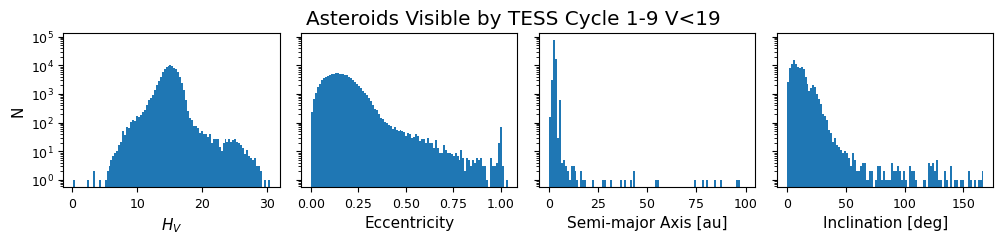

In [53]:
fig, ax = plt.subplots(1, 4, figsize=(12, 2), sharey=True)
fig.suptitle("Asteroids Visible by TESS Cycle 1-9 V<19", y=1.0, fontsize="x-large")

ax[0].hist(uniq_cat["Absolute magntiude (H)"].values, bins=100, log=True)
ax[0].set_xlabel("$H_{V}$", fontsize=11)
ax[0].set_ylabel("N", fontsize=11)

ax[1].hist(uniq_cat["Eccentricity"].values, bins=100, log=True)
ax[1].set_xlabel("Eccentricity", fontsize=11)

ax[2].hist(uniq_cat["semimajor_axis (au)"].values, bins=100, log=True, label="All", range=[0, 100])
ax[2].set_xlabel("Semi-major Axis [au]", fontsize=11)
# ax[2].set_ylabel("N", fontsize=11)
# ax[1, 0].set_xscale("log")

ax[3].hist(uniq_cat["Inclination (deg)"].values, bins=100, log=True)
ax[3].set_xlabel("Inclination [deg]", fontsize=11)

ax[0].tick_params(axis='both', which='major', labelsize=9)
ax[1].tick_params(axis='both', which='major', labelsize=9)
ax[2].tick_params(axis='both', which='major', labelsize=9)
ax[3].tick_params(axis='both', which='major', labelsize=9)

plt.subplots_adjust(wspace=0.1)

plt.savefig("./figures/c2_proposal/known_asteroids_dist_h2.pdf", bbox_inches='tight', pad_inches=0.01)

plt.show()

In [115]:
uniq_cat["Absolute magntiude (H)"].min(), uniq_cat["Absolute magntiude (H)"].max()

(0.14, 30.4)

In [104]:
from matplotlib.ticker import ScalarFormatter

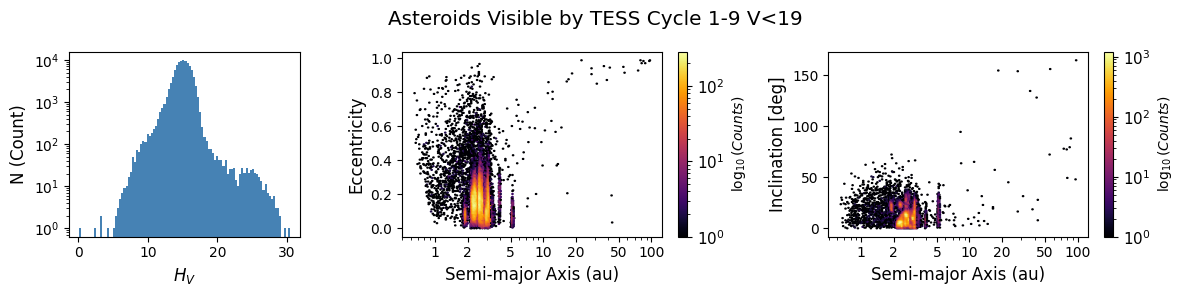

In [112]:
# 1. Setup the figure
# We keep your width_ratios; they help accommodate the colorbars on the right two plots
fig, ax = plt.subplots(1, 3, figsize=(12, 3), sharey=False, width_ratios=[1, 1.4, 1.4])
fig.suptitle("Asteroids Visible by TESS Cycle 1-9 V<19", y=0.97, fontsize="x-large")

# --- Plot 0: Histogram of Absolute Magnitude ---
ax[0].hist(uniq_cat["Absolute magntiude (H)"].values, bins=100, log=True, color='steelblue', edgecolor='none')
ax[0].set_xlabel("$H_{V}$", fontsize=12)
ax[0].set_ylabel("N (Count)", fontsize=12)
# ax[0].grid(True, which="both", ls="-", alpha=0.2)

# Data filtering for orbital parameters
mask = (uniq_cat["semimajor_axis (au)"].values > 0) & (uniq_cat["semimajor_axis (au)"].values < 100)
x_data = uniq_cat["semimajor_axis (au)"].values[mask]
y_ecc = uniq_cat["Eccentricity"].values[mask]
y_inc = uniq_cat["Inclination (deg)"].values[mask]

# --- Plot 1: Eccentricity vs Semimajor Axis ---
# Note: Use xscale='log' for hexbin to handle the binning correctly in log-space
hb1 = ax[1].hexbin(x_data, y_ecc, gridsize=200, bins='log', cmap='inferno', xscale='log')
cb1 = fig.colorbar(hb1, ax=ax[1], label='$\log_{10}(Counts)$')
cb1.ax.tick_params(labelsize=11)

ax[1].set_ylabel("Eccentricity", fontsize=12)
ax[1].set_xlabel("Semi-major Axis (au)", fontsize=12)

# --- Plot 2: Inclination vs Semi-major Axis ---
hb2 = ax[2].hexbin(x_data, y_inc, gridsize=200, bins='log', cmap='inferno', xscale='log')
cb2 = fig.colorbar(hb2, ax=ax[2], label='$\log_{10}(Counts)$')
cb2.ax.tick_params(labelsize=11)

ax[2].set_ylabel("Inclination [deg]", fontsize=12)
ax[2].set_xlabel("Semi-major Axis (au)", fontsize=12)

# --- Formatting Fixes ---
for a in [ax[1], ax[2]]:
    # This makes the log axis show 1, 10, 100 instead of 10^0, 10^1...
    a.xaxis.set_major_formatter(ScalarFormatter())
    a.set_xticks([1, 2, 5, 10, 20, 50, 100]) # Custom ticks often look better in Astro plots

plt.tight_layout()
plt.savefig("./figures/c2_proposal/known_asteroids_dist_h1.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()

In [86]:
10 ** ax[2].get_xticklabels()

[Text(-0.5, 0, '−0.5'),
 Text(0.0, 0, '0.0'),
 Text(0.5, 0, '0.5'),
 Text(1.0, 0, '1.0'),
 Text(1.5, 0, '1.5'),
 Text(2.0, 0, '2.0'),
 Text(2.5, 0, '2.5')]

In [123]:
biary_observ = pd.read_csv("./data/known_binary_asteroids_TESSobserv.txt", index_col=0)
biary_observ["SPK ID"] = [int(f"2{int(x):07}") if " " not in x else -1000 for x in biary_observ.target]
biary_observ["prov_disp"] = [x if " " in x else "" for x in biary_observ.target]
biary_observ

,sector,camera,ccd,dur,vmag,target,SPK ID,prov_disp
0,12,1,3,5.0,11.198833,22,20000022,
1,29,1,2,20.0,10.899714,22,20000022,
2,29,1,1,2.0,10.898000,22,20000022,
3,43,4,4,17.0,11.896333,22,20000022,
4,44,3,4,23.0,11.526750,22,20000022,
...,...,...,...,...,...,...,...,...
2179,5,2,4,15.0,24.159375,2024 YU4,-1000,2024 YU4
2180,31,2,3,4.0,23.392400,2024 YU4,-1000,2024 YU4
2181,31,2,4,21.0,23.504091,2024 YU4,-1000,2024 YU4
2182,97,2,2,7.0,23.091375,2024 YU4,-1000,2024 YU4


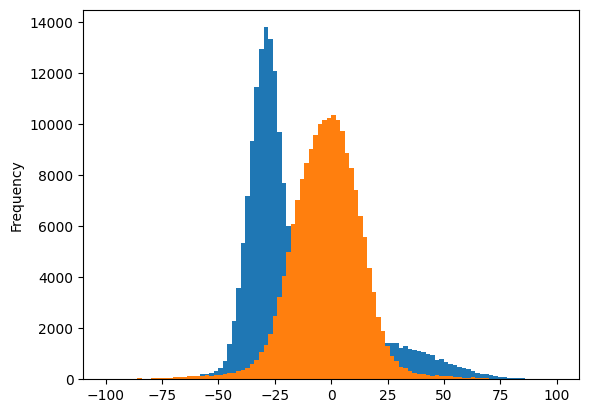

In [150]:
full_cat['RA rate ("/h)'].plot(kind="hist", bins=100, range=[-100, 100])
full_cat['Dec rate ("/h)'].plot(kind="hist", bins=100, range=[-100, 100])
plt.show()

In [172]:
mask1 = ((full_cat['Visual magnitude'] <= 18) & 
        (full_cat['Visual magnitude'] > 15)
       )
mask2 = (np.abs(full_cat['RA rate ("/h)']) > 100) | (np.abs(full_cat['Dec rate ("/h)']) > 100)
        # (np.abs(full_cat['Dec rate ("/h)']) > 50)
fast_n_faint = full_cat[mask1 & mask2]
fast_n_faint

,SPK ID,Object name,pdes,IAU name,track_name,sector,camera,ccd,file_name,Visual magnitude,...,pixel rate (pix/d),"RA rate (""/h)","Dec rate (""/h)",Absolute magntiude (H),Eccentricity,Inclination (deg),Perihelion (au),tstart (jd),tstop (jd),semimajor_axis (au)
51,20099799,99799 (2002 LJ3),99799,NaN,2002-LJ3,1,1,4,tess-ffi_s0001-0-0_2002-LJ3_hires.feather,15.695313,...,162.128285,-27.46,-106.500,18.54,0.275755,7.557347,1.058825,2.458333e+06,2.458345e+06,1.461971
62,20099799,99799 (2002 LJ3),99799,NaN,2002-LJ3,1,1,1,tess-ffi_s0001-0-0_2002-LJ3_hires.feather,15.766816,...,208.628028,-27.46,-106.500,18.54,0.275755,7.557347,1.058825,2.458346e+06,2.458353e+06,1.461971
77,20620070,620070 (2011 UA),620070,NaN,2011-UA,1,3,4,tess-ffi_s0001-0-0_2011-UA_hires.feather,16.012536,...,452.898695,-122.70,-101.800,18.62,0.547890,8.921624,1.035911,2.458335e+06,2.458340e+06,2.291282
88,20620070,620070 (2011 UA),620070,NaN,2011-UA,1,4,1,tess-ffi_s0001-0-0_2011-UA_hires.feather,16.119080,...,475.658623,-122.70,-101.800,18.62,0.547890,8.921624,1.035911,2.458335e+06,2.458335e+06,2.291282
104,20620070,620070 (2011 UA),620070,NaN,2011-UA,1,4,2,tess-ffi_s0001-0-0_2011-UA_hires.feather,16.328152,...,410.412987,-122.70,-101.800,18.62,0.547890,8.921624,1.035911,2.458330e+06,2.458335e+06,2.291282
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186461,20159699,159699 (2002 PQ142),159699,NaN,2002-PQ142,117,3,3,tess-ffi_s0117-0-0_2002-PQ142_lores.feather,17.797500,...,270.035527,-192.80,-112.000,17.60,0.715935,16.812227,0.482029,2.461538e+06,2.461544e+06,1.696896
186550,20159699,159699 (2002 PQ142),159699,NaN,2002-PQ142,117,3,2,tess-ffi_s0117-0-0_2002-PQ142_lores.feather,17.974300,...,214.932820,-192.80,-112.000,17.60,0.715935,16.812227,0.482029,2.461544e+06,2.461554e+06,1.696896
188005,20242191,242191 (2003 NZ6),242191,NaN,2003-NZ6,118,3,1,tess-ffi_s0118-0-0_2003-NZ6_lores.feather,17.524000,...,NaN,-265.60,-61.830,19.02,0.492336,18.247051,0.402786,2.461588e+06,2.461588e+06,0.793410
188088,20242191,242191 (2003 NZ6),242191,NaN,2003-NZ6,118,3,2,tess-ffi_s0118-0-0_2003-NZ6_lores.feather,17.720286,...,288.147022,-265.60,-61.830,19.02,0.492336,18.247051,0.402786,2.461582e+06,2.461588e+06,0.793410


In [173]:
examples1 = pd.merge(biary_observ, fast_n_faint, 
         left_on=["SPK ID", "sector", "camera", "ccd"], 
         right_on=["SPK ID", "sector", "camera", "ccd"], 
         how="inner")
# examples2 = pd.merge(biary_observ, fast_n_faint, 
#          left_on=["SPK ID", "sector", "camera", "ccd"], 
#          right_on=["SPK ID", "sector", "camera", "ccd"], 
#          how="inner")
# examples1

In [174]:
with pd.option_context('display.max_rows', None):
    display(examples1.query("dur > 1"))

,sector,camera,ccd,dur,vmag,target,SPK ID,prov_disp,Object name,pdes,...,pixel rate (pix/d),"RA rate (""/h)","Dec rate (""/h)",Absolute magntiude (H),Eccentricity,Inclination (deg),Perihelion (au),tstart (jd),tstop (jd),semimajor_axis (au)
0,44,4,4,16.0,17.845000,8373,20008373,,8373 Stephengould (1992 AB),8373,...,134.383001,104.60,28.47,14.31,0.555533,40.799914,1.456848,2.459500e+06,2.459517e+06,3.277739
1,65,1,3,7.0,17.381625,69230,20069230,,69230 Hermes (1937 UB),69230,...,116.456841,-103.40,13.73,17.68,0.623918,6.067328,0.622442,2.460089e+06,2.460097e+06,1.655067
3,72,2,2,7.0,17.529250,85628,20085628,,85628 (1998 KV2),85628,...,243.396792,192.00,37.88,17.28,0.331561,13.026393,1.064294,2.460260e+06,2.460268e+06,1.592208
5,41,1,4,5.0,15.339167,285571,20285571,,285571 (2000 PQ9),285571,...,397.682672,-18.53,271.20,18.65,0.432441,13.482667,1.080386,2.459427e+06,2.459433e+06,1.903566
6,41,1,1,4.0,16.063000,285571,20285571,,285571 (2000 PQ9),285571,...,180.261195,-18.53,271.20,18.65,0.432441,13.482667,1.080386,2.459434e+06,2.459439e+06,1.903566
7,54,1,3,4.0,16.511200,377732,20377732,,377732 (2005 XJ8),377732,...,198.392534,-111.80,-141.00,17.06,0.620503,23.559144,0.732966,2.459770e+06,2.459775e+06,1.931417
8,41,2,4,3.0,16.824250,523664,20523664,,523664 (2012 OD1),523664,...,539.072598,-342.50,-195.70,18.52,0.502911,42.261542,0.411970,2.459428e+06,2.459432e+06,0.828766
9,41,2,3,5.0,17.499000,523664,20523664,,523664 (2012 OD1),523664,...,339.853512,-342.50,-195.70,18.52,0.502911,42.261542,0.411970,2.459433e+06,2.459439e+06,0.828766
10,24,1,2,2.0,16.873000,539940,20539940,,539940 (2017 HW1),539940,...,313.218675,-151.80,-221.70,18.01,0.459290,33.959822,1.155342,2.458956e+06,2.458959e+06,2.136714
11,35,1,3,5.0,17.836667,612098,20612098,,612098 (1999 RM45),612098,...,23.780812,-175.30,47.82,19.82,0.644692,10.891401,0.598074,2.459255e+06,2.459260e+06,1.683256
